20075


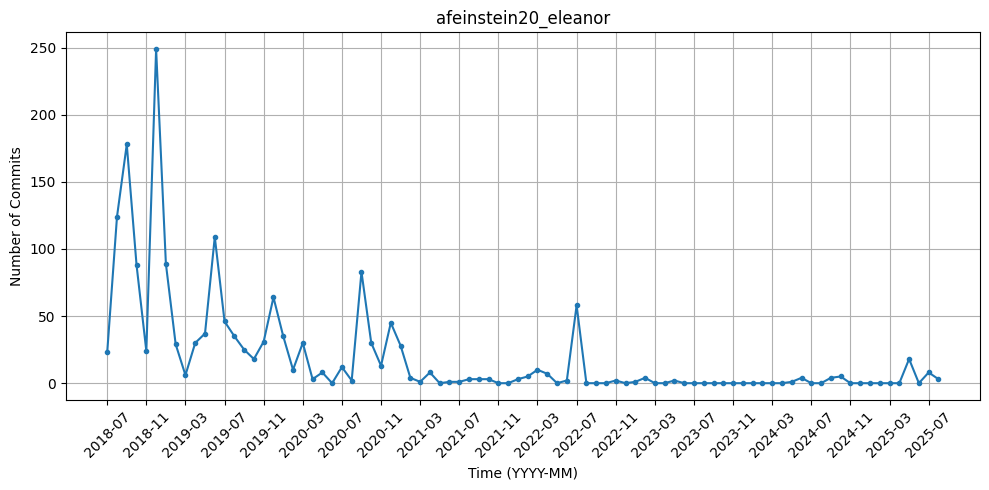

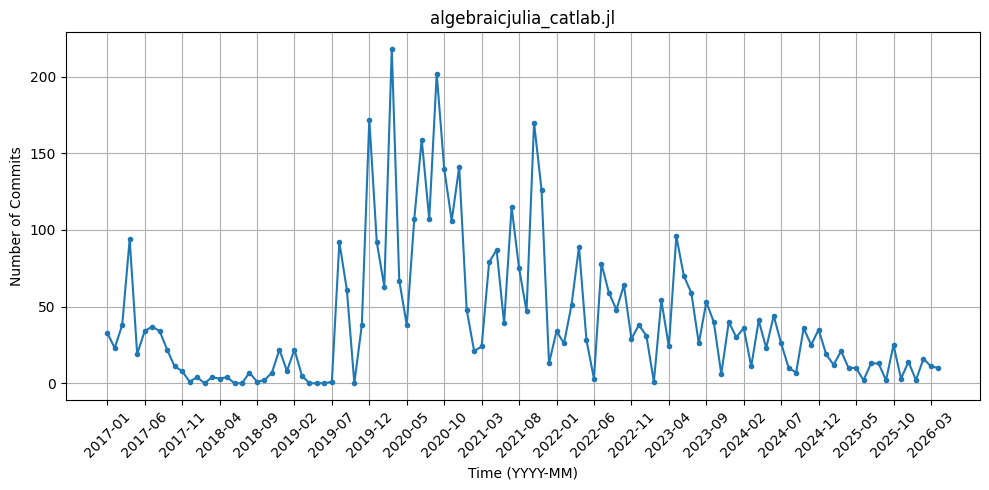

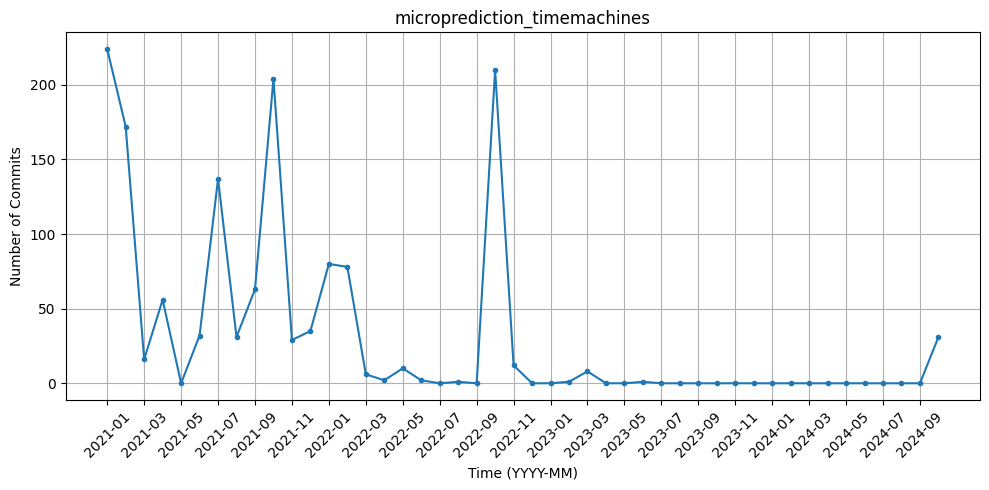

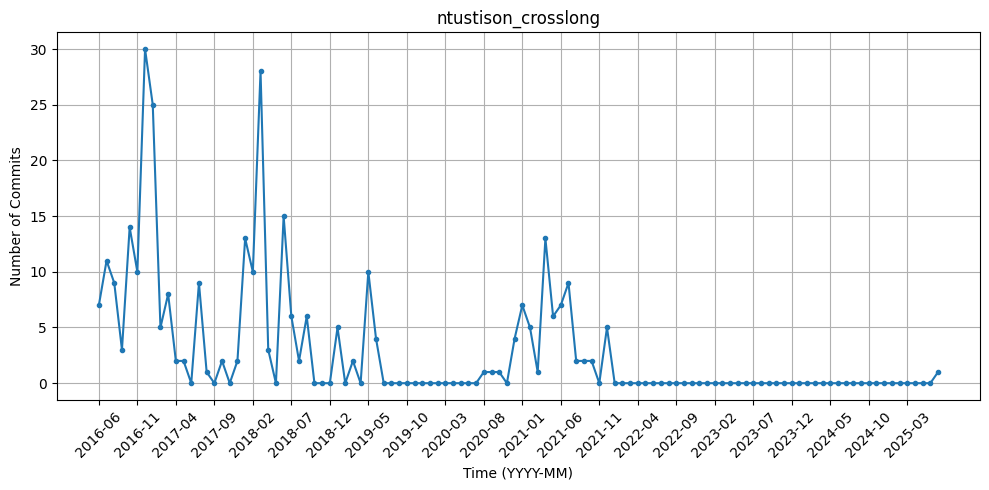

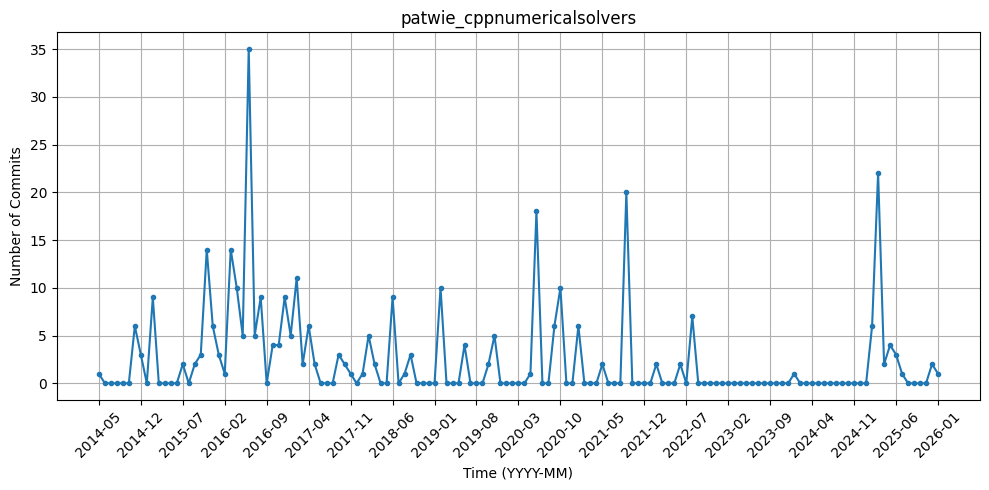

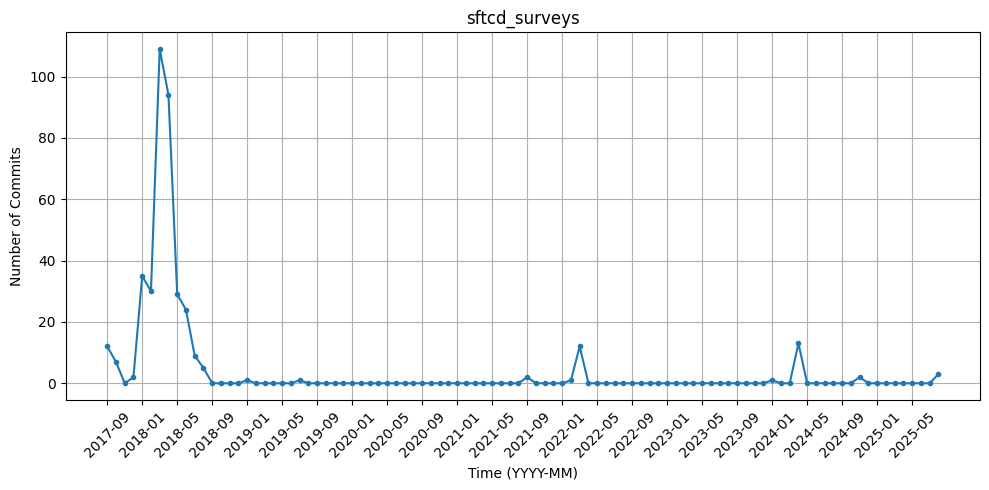

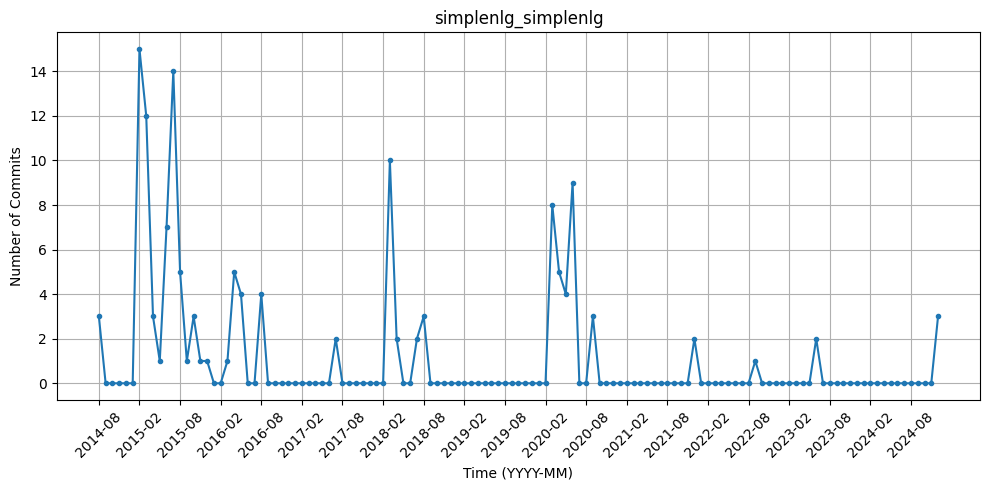

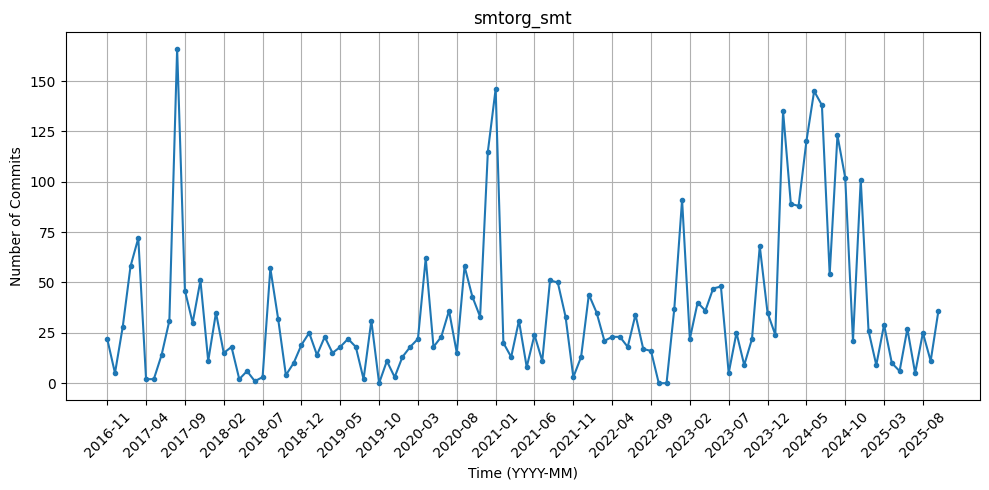

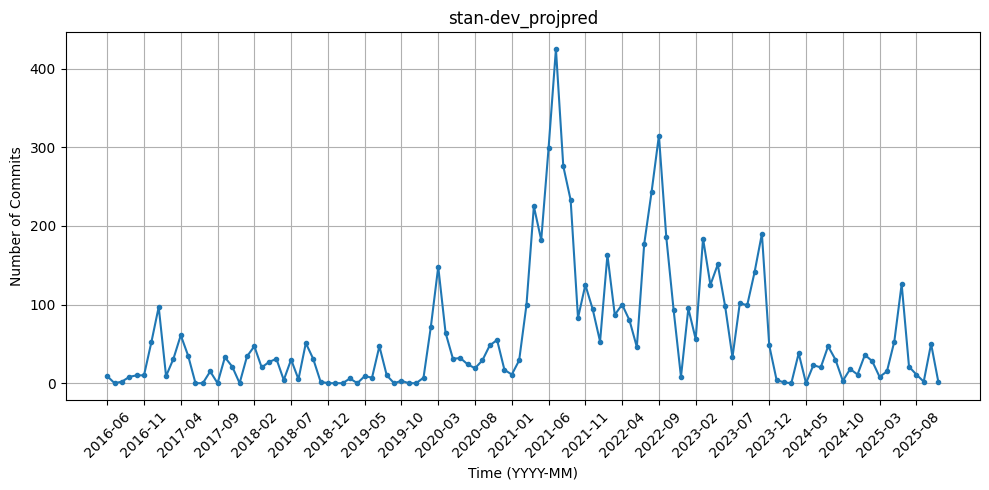

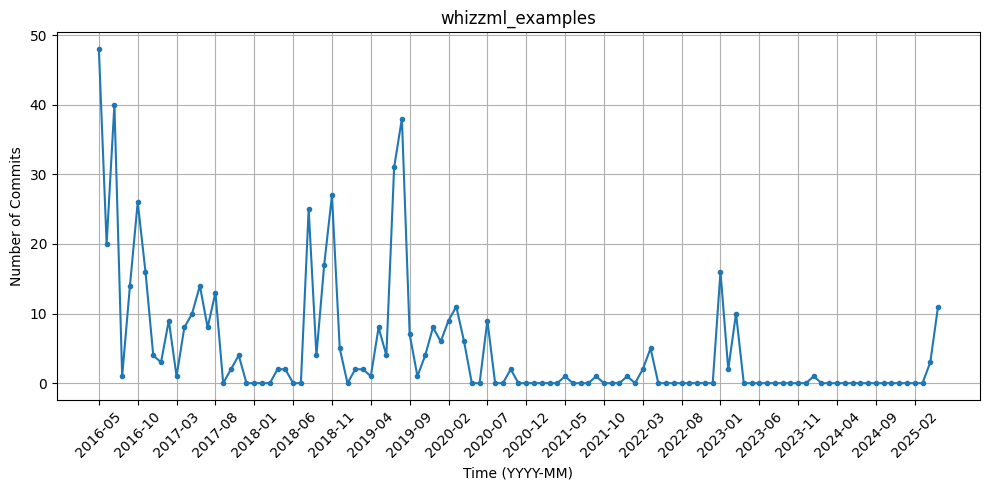

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

netid = 'ncash3'
cols = ['project_wocid', 'commit_sha1', 'author', 'time', 'commit_message']
d = pd.read_csv(f'{netid}_project_summary.csv', sep=';', header=None, names=cols)
print(len(d))   

d['month'] = pd.to_datetime(d['time'], unit='s').dt.to_period('M')

series = {}
for prj, g in d.groupby('project_wocid'):
    counts = g.groupby('month').size()
    full = pd.period_range(counts.index.min(), counts.index.max(), freq='M')
    counts = counts.reindex(full, fill_value=0)          # zero-commit months included
    ts = pd.DataFrame({'Month': counts.index.strftime('%Y-%m'), '#Commits': counts.values})
    ts.to_csv(f'{netid}_commits_timeseries_{prj}.csv', sep=';', index=False)
    series[prj] = ts

    x = list(range(len(ts)))
    step = max(1, len(ts) // 20)
    plt.figure(figsize=(10, 5))
    plt.plot(x, ts['#Commits'], marker='o', markersize=3, linestyle='-')
    plt.xticks(x[::step], ts['Month'].tolist()[::step], rotation=45)
    plt.xlabel('Time (YYYY-MM)')
    plt.ylabel('Number of Commits')
    plt.title(prj)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f'{netid}_timeseries_{prj}.png', dpi=300)
    plt.show()    
    plt.close()

In [4]:
def zero_runs(ts):
    runs, start = [], None
    for i, c in enumerate(ts['#Commits']):
        if c == 0 and start is None:
            start = i
        elif c != 0 and start is not None:
            runs.append((start, i - 1))
            start = None
    return runs    

rows = []
for prj, ts in series.items():
    g = d[d['project_wocid'] == prj]
    t = pd.to_datetime(g['time'], unit='s')
    runs = zero_runs(ts)
    row = {
        'Project': prj,
        'ncommits': g['commit_sha1'].nunique(),
        'nauthors': g['author'].nunique(),
        'from': t.min().strftime('%Y-%m-%d'),
        'to': t.max().strftime('%Y-%m-%d'),
    }
    if runs:
        s, e = max(runs, key=lambda r: r[1] - r[0])     
        row.update({
            'LongestGapStart': ts['Month'].iloc[s],
            'LongestGapEnd': ts['Month'].iloc[e],
            'LongestGapLength': e - s + 1,
            'NumCommitsAfterLastGap': int(ts['#Commits'].iloc[e + 1:].sum()),
        })
    else:
        row.update({'LongestGapStart': '', 'LongestGapEnd': '', 'LongestGapLength': 0,
                    'NumCommitsAfterLastGap': 0})
    row['NumberOfGapsInTimeline'] = sum(1 for s, e in runs if e - s + 1 >= 3)
    rows.append(row)

stats = pd.DataFrame(rows)
stats

,Project,ncommits,nauthors,from,to,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
0,afeinstein20_eleanor,1665,40,2018-07-24,2025-08-26,2023-06,2024-04,11,43,3
1,algebraicjulia_catlab.jl,4645,88,2017-01-24,2026-04-17,2019-04,2019-06,3,4202,1
2,microprediction_timemachines,1441,14,2021-01-04,2024-10-21,2023-07,2024-09,15,31,1
3,ntustison_crosslong,311,23,2016-06-29,2025-07-16,2022-01,2025-06,42,1,3
4,patwie_cppnumericalsolvers,335,40,2014-05-29,2026-01-08,2022-09,2023-12,16,42,14
5,sftcd_surveys,392,11,2017-09-15,2025-08-14,2019-08,2021-08,25,34,7
6,simplenlg_simplenlg,136,23,2014-08-20,2024-12-06,2018-09,2020-02,18,37,8
7,smtorg_smt,3821,98,2016-11-08,2025-10-31,2022-10,2022-11,2,1809,0
8,stan-dev_projpred,6804,34,2016-06-16,2025-11-01,2018-12,2019-02,3,6129,1
9,whizzml_examples,525,27,2016-05-14,2025-05-23,2024-02,2025-03,14,14,7


In [5]:
gh = {
    'patwie_cppnumericalsolvers':   (978, 205, '2026-07-24T14:45:03Z'),
    'simplenlg_simplenlg':          (832, 185, '2024-12-06T12:07:07Z'),
    'ntustison_crosslong':          (0, 0,     '2026-08-11T20:35:10Z'),
    'stan-dev_projpred':            (114, 31,  '2026-09-26T10:10:01Z'),
    'whizzml_examples':             (24, 42,   '2025-05-23T17:56:00Z'),
    'afeinstein20_eleanor':         (101, 43,  '2026-07-17T21:38:37Z'),
    'smtorg_smt':                   (916, 231, '2026-09-17T08:03:24Z'),
    'algebraicjulia_catlab.jl':     (727, 73,  '2026-07-02T15:25:46Z'),
    'microprediction_timemachines': (443, 54,  '2026-09-24T16:28:02Z'),
    'sftcd_surveys':                (5, 5,     '2026-07-03T19:23:22Z'),
}
stats['nstars'] = stats['Project'].map(lambda p: gh[p][0])
stats['nforks'] = stats['Project'].map(lambda p: gh[p][1])
stats['lastGHCommitDate'] = stats['Project'].map(lambda p: gh[p][2])

activity = {
    'afeinstein20_eleanor': 'declining',
    'algebraicjulia_catlab.jl': 'declining',
    'microprediction_timemachines': 'declining',
    'ntustison_crosslong': 'declining',
    'patwie_cppnumericalsolvers': 'U-shaped',
    'sftcd_surveys': 'irregular',
    'simplenlg_simplenlg': 'irregular',
    'smtorg_smt': 'steady',
    'stan-dev_projpred': 'declining',
    'whizzml_examples': 'declining',
}
stats['ActivityPattern'] = stats['Project'].map(activity)

before = {
    'afeinstein20_eleanor': 'Bug fixes:Feature development',
    'algebraicjulia_catlab.jl': 'Feature development:Dependency updates',
    'microprediction_timemachines': 'Other:Feature development',
    'ntustison_crosslong': 'Feature development:Other',
    'patwie_cppnumericalsolvers': 'Bug fixes:Other',
    'sftcd_surveys': 'Bug fixes:Feature development',
    'simplenlg_simplenlg': 'Documentation updates:Bug fixes',
    'smtorg_smt': 'Feature development:Documentation updates',
    'stan-dev_projpred': 'Documentation updates:Other',
    'whizzml_examples': 'Documentation updates:Bug fixes',
}
after = {
    'afeinstein20_eleanor': 'Bug fixes:Feature development',
    'algebraicjulia_catlab.jl': 'Documentation updates:Other',
    'microprediction_timemachines': 'Documentation updates:Other',
    'ntustison_crosslong': 'Documentation updates',
    'patwie_cppnumericalsolvers': 'Feature development:Other',
    'sftcd_surveys': 'Feature development:Other',
    'simplenlg_simplenlg': 'Bug fixes:Documentation updates',
    'smtorg_smt': 'Feature development:Bug fixes',
    'stan-dev_projpred': 'Bug fixes:Dependency updates',
    'whizzml_examples': 'Feature development:Bug fixes',
}
stats['BeforeThemes'] = stats['Project'].map(before)
stats['AfterThemes'] = stats['Project'].map(after)

order = ['Project', 'ncommits', 'nauthors', 'from', 'to', 'nstars', 'nforks', 'lastGHCommitDate',
         'LongestGapStart', 'LongestGapEnd', 'LongestGapLength', 'NumCommitsAfterLastGap',
         'ActivityPattern', 'NumberOfGapsInTimeline', 'BeforeThemes', 'AfterThemes']
stats[order].to_csv('ncash3_project_stats.csv', sep=';', index=False)
stats[order]

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,ActivityPattern,NumberOfGapsInTimeline,BeforeThemes,AfterThemes
0,afeinstein20_eleanor,1665,40,2018-07-24,2025-08-26,101,43,2026-07-17T21:38:37Z,2023-06,2024-04,11,43,declining,3,Bug fixes:Feature development,Bug fixes:Feature development
1,algebraicjulia_catlab.jl,4645,88,2017-01-24,2026-04-17,727,73,2026-07-02T15:25:46Z,2019-04,2019-06,3,4202,declining,1,Feature development:Dependency updates,Documentation updates:Other
2,microprediction_timemachines,1441,14,2021-01-04,2024-10-21,443,54,2026-09-24T16:28:02Z,2023-07,2024-09,15,31,declining,1,Other:Feature development,Documentation updates:Other
3,ntustison_crosslong,311,23,2016-06-29,2025-07-16,0,0,2026-08-11T20:35:10Z,2022-01,2025-06,42,1,declining,3,Feature development:Other,Documentation updates
4,patwie_cppnumericalsolvers,335,40,2014-05-29,2026-01-08,978,205,2026-07-24T14:45:03Z,2022-09,2023-12,16,42,U-shaped,14,Bug fixes:Other,Feature development:Other
5,sftcd_surveys,392,11,2017-09-15,2025-08-14,5,5,2026-07-03T19:23:22Z,2019-08,2021-08,25,34,irregular,7,Bug fixes:Feature development,Feature development:Other
6,simplenlg_simplenlg,136,23,2014-08-20,2024-12-06,832,185,2024-12-06T12:07:07Z,2018-09,2020-02,18,37,irregular,8,Documentation updates:Bug fixes,Bug fixes:Documentation updates
7,smtorg_smt,3821,98,2016-11-08,2025-10-31,916,231,2026-09-17T08:03:24Z,2022-10,2022-11,2,1809,steady,0,Feature development:Documentation updates,Feature development:Bug fixes
8,stan-dev_projpred,6804,34,2016-06-16,2025-11-01,114,31,2026-09-26T10:10:01Z,2018-12,2019-02,3,6129,declining,1,Documentation updates:Other,Bug fixes:Dependency updates
9,whizzml_examples,525,27,2016-05-14,2025-05-23,24,42,2025-05-23T17:56:00Z,2024-02,2025-03,14,14,declining,7,Documentation updates:Bug fixes,Feature development:Bug fixes


In [9]:
status = {p: 'Active' for p in stats['Project']}
status['simplenlg_simplenlg'] = 'Inactive'
stats['Currentstatus'] = stats['Project'].map(status)

In [10]:
rows = []
for _, r in stats.iterrows():
    prj = r['Project']
    gs = pd.Period(r['LongestGapStart'], 'M')
    ge = pd.Period(r['LongestGapEnd'], 'M')
    g = d[d['project_wocid'] == prj].sort_values('time')
    pre = g[g['month'] < gs].tail(10).assign(prepost='pre')     # last 10 before the gap
    post = g[g['month'] > ge].head(10).assign(prepost='post')   # first 10 after the gap
    rows.append(pd.concat([pre, post]))

gap = pd.concat(rows)
gap_out = gap[['prepost', 'project_wocid', 'commit_sha1', 'author', 'time', 'commit_message']]
gap_out.to_csv('ncash3_project_gap_commits.csv', sep=';', index=False, header=False)

# print the first line of each message so the themes can be classified
for prj, g in gap_out.groupby('project_wocid'):
    print('=====', prj)
    for _, x in g.iterrows():
        print(x['prepost'], '|', x['commit_message'].strip().split('\n')[0][:100])

===== afeinstein20_eleanor
pre | gaia dr3 in changelog
pre | move tensorflow imports into functions so the package will load without it
pre | use 20-sec cadence targets for the new 200s FFIs
pre | Merge pull request #262 from ethankruse/newcadence
pre | fix update_max_sector() : update the proper maxsector.py
pre | Merge 8eddbbcaca54da33e973285e409a3a27516ab032 into 4a5eceb71cffb9a3d1b44aa24db0c1aa0524df41
pre | bug fix: aperture_contour() does not return figure created
pre | Merge eddbe7e181d638e4c9d0968014daffaae0ed5f9f into 4a5eceb71cffb9a3d1b44aa24db0c1aa0524df41
pre | fix eleanor and future-proof through Year 6
pre | Merge d642906c0ac3a96d30d9465dba41fe92d2936d1c into 4a5eceb71cffb9a3d1b44aa24db0c1aa0524df41
post | update script fixes for new fields, faster cadences
post | clean up update script for new fields
post | tweak for Sector 65 missing data in 4-4
post | Merge 8eddbbcaca54da33e973285e409a3a27516ab032 into 05e8e8db9eab865dcfa632406cc1eab3cc3b756b
post | Merge eddbe7e181d63

In [11]:
for _, r in stats.iterrows():
    prj = r['Project']
    gs = pd.Period(r['LongestGapStart'], 'M')
    ge = pd.Period(r['LongestGapEnd'], 'M')
    g = d[d['project_wocid'] == prj]
    before = set(g[g['month'] < gs]['author'])
    after = g[g['month'] > ge]
    after_set = set(after['author'])
    print(f"== {prj}: {len(before)} authors before gap, {len(after_set)} after, "
          f"{len(before & after_set)} in both, {len(after_set - before)} new")
    print(after['author'].value_counts().head(3).to_string())

import requests, time
repos = {
    'patwie_cppnumericalsolvers': 'PatWie/CppNumericalSolvers',
    'simplenlg_simplenlg': 'simplenlg/simplenlg',
    'ntustison_crosslong': 'ntustison/CrossLong',
    'stan-dev_projpred': 'stan-dev/projpred',
    'whizzml_examples': 'whizzml/examples',
    'afeinstein20_eleanor': 'afeinstein20/eleanor',
    'smtorg_smt': 'SMTorg/smt',
    'algebraicjulia_catlab.jl': 'AlgebraicJulia/Catlab.jl',
    'microprediction_timemachines': 'microprediction/timemachines',
    'sftcd_surveys': 'sftcd/surveys',
}
for prj, repo in repos.items():
    print('=====', prj)
    for c in requests.get(f'https://api.github.com/repos/{repo}/commits', params={'per_page': 10}).json():
        print(c['commit']['author']['date'][:10], '|', c['commit']['author']['name'], '|',
              c['commit']['message'].split('\n')[0][:90])
    time.sleep(1)

== afeinstein20_eleanor: 37 authors before gap, 8 after, 5 in both, 3 new
author
Adina Feinstein <adina.d.feinstein@gmail.com>    15
zzyu17 <zzyu06@163.com>                           9
orionlee <orionlee@yahoo.com>                     7
== algebraicjulia_catlab.jl: 2 authors before gap, 88 after, 2 in both, 86 new
author
Evan Patterson <evan@epatters.org>                1410
Documenter.jl <documenter@juliadocs.github.io>     623
epatters <ejpatters@gmail.com>                     461
== microprediction_timemachines: 14 authors before gap, 2 after, 2 in both, 0 new
author
Peter Cotton <57455669+microprediction@users.noreply.github.com>    28
Peter Cotton <peter.cotton@microprediction.com>                      3
== ntustison_crosslong: 23 authors before gap, 1 after, 1 in both, 0 new
author
Nick Tustison <ntustison@gmail.com>    1
== patwie_cppnumericalsolvers: 38 authors before gap, 3 after, 1 in both, 2 new
author
patwie <mail@patwie.com>                                 39
Nilesh Patra 

# Identify the Longest Inactivity Gap

2022-02 to 2023-04

Add all that info to netid_project_stats.csv

## Interpretation

- **afeinstein20_eleanor (declining, 3 gaps):** Peak activity in 2018-2019 (686 and 519 commits), then a steady fall to under 100 a year. Longest gap 2023-06 to 2024-04 (11 months), with 43 commits after it.
- **algebraicjulia_catlab.jl (declining, 1 gap):** Grew quickly to a peak of 1440 commits in 2020, then slowed each year. Only one gap (2019-04 to 2019-06), so activity has been mostly continuous.
- **microprediction_timemachines (declining, 1 gap):** Most activity was in 2021 (999 commits), falling to 10 in 2023. Longest gap 2023-07 to 2024-09 (15 months), with 31 commits after it.
- **ntustison_crosslong (declining, 3 gaps):** Small bursts through 2021, then essentially nothing. Longest gap 2022-01 to 2025-06 (42 months), with 1 commit after it.
- **patwie_cppnumericalsolvers (U-shaped, 14 gaps):** Most active in 2014-2016, near zero by 2023, then a revival in 2025 (40 commits). The most gaps of any project; longest 2022-09 to 2023-12 (16 months).
- **sftcd_surveys (irregular, 7 gaps):** One burst in 2017-2018 (356 commits) followed by sporadic activity. Longest gap 2019-08 to 2021-08 (25 months).
- **simplenlg_simplenlg (irregular, 8 gaps):** Short spike in 2015 (63 commits), otherwise a few commits a year. Longest gap 2018-09 to 2020-02 (18 months).
- **smtorg_smt (steady, 0 gaps):** Consistently active every year, with a peak in 2024 (1140 commits). Longest zero-commit stretch is only 2 months.
- **stan-dev_projpred (declining, 1 gap):** There is a peak in 2021 (2082 commits), then a gradual decline. The only gap is 3 months (2018-12 to 2019-02).
- **whizzml_examples (declining, 7 gaps):** Most activity in 2016-2018, then very little. Longest gap 2024-02 to 2025-03 (14 months).

In [13]:
hyp = {
 'afeinstein20_eleanor': "No new TESS data to support; last pre-gap commits were cadence and changelog updates",
 'algebraicjulia_catlab.jl': "Short early pause after the v0.2.1 release and dropping Julia 0.7",
 'microprediction_timemachines': "Maintainer likely moved on; pre-gap commits were small notebook, test, and setup edits",
 'ntustison_crosslong': "Research analysis likely finished; pre-gap commits were model runs and data dumps",
 'patwie_cppnumericalsolvers': "Maintenance mode with one maintainer; pre-gap commits were small bug fixes.",
 'sftcd_surveys': "Survey study likely complete; pre-gap commits were final script tweaks.",
 'simplenlg_simplenlg': "Part-time maintainer and low demand; pre-gap commits were merged outside PRs and README edits.",
 'smtorg_smt': "N/A active Project",
 'stan-dev_projpred': "Brief pause after documentation updates, likely before a CRAN release.",
 'whizzml_examples': "Work likely finished; pre-gap commits were documentation polishing.",
}
recovered = {p: 'Yes' for p in stats['Project']}
recovered['ntustison_crosslong'] = 'No'
recovered['smtorg_smt'] = 'N/A'
why = {
 'afeinstein20_eleanor': "New TESS fields, faster cadences, and Sector 65 data needed support",
 'algebraicjulia_catlab.jl': "Normal development resumed with new notebooks and cleanup",
 'microprediction_timemachines': "Maintainer returned to fix CI workflows and refresh docs",
 'ntustison_crosslong': "N/A",
 'patwie_cppnumericalsolvers': "Major rewrite: Bazel 8, Nelder-Mead, constrained optimization, faster L-BFGS",
 'sftcd_surveys': "New contributors extended the scripts (MaxMind GeoIP tooling)",
 'simplenlg_simplenlg': "Fixes for newer JDKs and numbered issue reports (#54, #65, #75, #76)",
 'smtorg_smt': "N/A",
 'stan-dev_projpred': "CRAN fixes, news updates and test fixes",
 'whizzml_examples': "New time series preprocessing utilities",
}
who = {
 'afeinstein20_eleanor': "Mostly the same maintainer, plus a few new contributors.",
 'algebraicjulia_catlab.jl': "Same core maintainer, with many new authors joining later.",
 'microprediction_timemachines': "Same person, no new authors.",
 'ntustison_crosslong': "Same person (1 commit).",
 'patwie_cppnumericalsolvers': "Same maintainer, plus 2 new authors.",
 'sftcd_surveys': "Mostly new people (pushldr, Rahul Seth).",
 'simplenlg_simplenlg': "Same maintainer plus new contributors.",
 'smtorg_smt': "N/A",
 'stan-dev_projpred': "Mixed: core maintainers plus many new authors.",
 'whizzml_examples': "Same person.",
}
status = {p: 'Active' for p in stats['Project']}
status['simplenlg_simplenlg'] = 'Inactive' 
recent = {
 'afeinstein20_eleanor': 'Bug fixes: Other',
 'algebraicjulia_catlab.jl': 'Dependency updates:Other',
 'microprediction_timemachines': 'Documentation updates: Other',
 'ntustison_crosslong': 'Other',
 'patwie_cppnumericalsolvers': 'Other: Bug fixes',
 'sftcd_surveys': 'Dependency updates: Other',
 'simplenlg_simplenlg': 'Documentation updates: Dependency updates',
 'smtorg_smt': 'Automated bot contributions: Documentation updates',
 'stan-dev_projpred': 'Documentation updates: Release',
 'whizzml_examples': 'Feature development: Bug fixes',
}
notes = {
 'afeinstein20_eleanor': "Activity peaked in 2018-2019 and declined, with an 11-month longest gap (2023-06 to 2024-04). The gap was fairly easy to interpret, since work resumed when new TESS data needed support.",
 'algebraicjulia_catlab.jl': "Activity grew to a 2020 peak and then declined, with only one short gap (2019-04 to 2019-06). The gap was easy to interpret; bot accounts inflate the commit counts.",
 'microprediction_timemachines': "Most activity was in 2021, with a 15-month longest gap (2023-07 to 2024-09). The gap was hard to interpret; one maintainer likely left and returned to fix CI and docs.",
 'ntustison_crosslong': "Small bursts through 2021, then a 42-month gap (2022-01 to 2025-06) with one commit afterward. The gap was easy to interpret as a finished analysis, though GitHub shows only 1 commit against 311 in WoC",
 'patwie_cppnumericalsolvers': "U-shaped activity with 14 gaps and a 16-month longest gap (2022-09 to 2023-12). One maintainer likely returned for a v2.0 rewrite, which made the gap fairly easy to interpret",
 'sftcd_surveys': "One burst in 2017-2018, then sporadic work, with a 25-month longest gap (2019-08 to 2021-08). The study looks finished and new contributors restarted it, so the gap was moderately easy to interpret.",
 'simplenlg_simplenlg': "A 2015 spike then a few commits a year, with an 18-month longest gap (2018-09 to 2020-02). Users reporting JDK issues likely pulled the maintainer back, and the project is now inactive.",
 'smtorg_smt': "Active every year, and the longest zero-commit stretch is only 2 months (2022-10 to 2022-11). There was no real gap to interpret.",
 'stan-dev_projpred': "Activity peaked in 2021 and declined gradually, with one 3-month gap (2018-12 to 2019-02). The gap was easy to interpret as a CRAN release cycle",
 'whizzml_examples': "Most activity was in 2016-2018, with a 14-month longest gap (2024-02 to 2025-03). One maintainer returned to add time series utilities, so the gap was easy to interpret.",
}

stats['HypothesizedGapReason'] = stats['Project'].map(hyp)
stats['HasRecovered'] = stats['Project'].map(recovered)
stats['WhyRecovered'] = stats['Project'].map(why)
stats['WhoRecovered'] = stats['Project'].map(who)
stats['Currentstatus'] = stats['Project'].map(status)
stats['RecentThemes'] = stats['Project'].map(recent)
stats['Notes'] = stats['Project'].map(notes)

for p, text in notes.items():
    with open(f'ncash3_reflection_{p}.md', 'w') as f:
        f.write(f"# Reflection: {p}\n\n{text}\n")

order = ['Project', 'ncommits', 'nauthors', 'from', 'to', 'nstars', 'nforks', 'lastGHCommitDate',
         'LongestGapStart', 'LongestGapEnd', 'LongestGapLength', 'NumCommitsAfterLastGap',
         'ActivityPattern', 'NumberOfGapsInTimeline', 'BeforeThemes', 'AfterThemes',
         'HypothesizedGapReason', 'HasRecovered', 'WhyRecovered', 'WhoRecovered',
         'Currentstatus', 'RecentThemes', 'Notes']
stats[order].to_csv('ncash3_project_stats.csv', sep=';', index=False)
stats[order]

,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,...,NumberOfGapsInTimeline,BeforeThemes,AfterThemes,HypothesizedGapReason,HasRecovered,WhyRecovered,WhoRecovered,Currentstatus,RecentThemes,Notes
0,afeinstein20_eleanor,1665,40,2018-07-24,2025-08-26,101,43,2026-07-17T21:38:37Z,2023-06,2024-04,...,3,Bug fixes:Feature development,Bug fixes:Feature development,No new TESS data to support; last pre-gap comm...,Yes,"New TESS fields, faster cadences, and Sector 6...","Mostly the same maintainer, plus a few new con...",Active,Bug fixes: Other,"Activity peaked in 2018-2019 and declined, wit..."
1,algebraicjulia_catlab.jl,4645,88,2017-01-24,2026-04-17,727,73,2026-07-02T15:25:46Z,2019-04,2019-06,...,1,Feature development:Dependency updates,Documentation updates:Other,Short early pause after the v0.2.1 release and...,Yes,Normal development resumed with new notebooks ...,"Same core maintainer, with many new authors jo...",Active,Dependency updates:Other,Activity grew to a 2020 peak and then declined...
2,microprediction_timemachines,1441,14,2021-01-04,2024-10-21,443,54,2026-09-24T16:28:02Z,2023-07,2024-09,...,1,Other:Feature development,Documentation updates:Other,Maintainer likely moved on; pre-gap commits we...,Yes,Maintainer returned to fix CI workflows and re...,"Same person, no new authors.",Active,Documentation updates: Other,"Most activity was in 2021, with a 15-month lon..."
3,ntustison_crosslong,311,23,2016-06-29,2025-07-16,0,0,2026-08-11T20:35:10Z,2022-01,2025-06,...,3,Feature development:Other,Documentation updates,Research analysis likely finished; pre-gap com...,No,N/A,Same person (1 commit).,Active,Other,"Small bursts through 2021, then a 42-month gap..."
4,patwie_cppnumericalsolvers,335,40,2014-05-29,2026-01-08,978,205,2026-07-24T14:45:03Z,2022-09,2023-12,...,14,Bug fixes:Other,Feature development:Other,Maintenance mode with one maintainer; pre-gap ...,Yes,"Major rewrite: Bazel 8, Nelder-Mead, constrain...","Same maintainer, plus 2 new authors.",Active,Other: Bug fixes,U-shaped activity with 14 gaps and a 16-month ...
5,sftcd_surveys,392,11,2017-09-15,2025-08-14,5,5,2026-07-03T19:23:22Z,2019-08,2021-08,...,7,Bug fixes:Feature development,Feature development:Other,Survey study likely complete; pre-gap commits ...,Yes,New contributors extended the scripts (MaxMind...,"Mostly new people (pushldr, Rahul Seth).",Active,Dependency updates: Other,"One burst in 2017-2018, then sporadic work, wi..."
6,simplenlg_simplenlg,136,23,2014-08-20,2024-12-06,832,185,2024-12-06T12:07:07Z,2018-09,2020-02,...,8,Documentation updates:Bug fixes,Bug fixes:Documentation updates,Part-time maintainer and low demand; pre-gap c...,Yes,Fixes for newer JDKs and numbered issue report...,Same maintainer plus new contributors.,Inactive,Documentation updates: Dependency updates,"A 2015 spike then a few commits a year, with a..."
7,smtorg_smt,3821,98,2016-11-08,2025-10-31,916,231,2026-09-17T08:03:24Z,2022-10,2022-11,...,0,Feature development:Documentation updates,Feature development:Bug fixes,N/A active Project,N/A,N/A,N/A,Active,Automated bot contributions: Documentation upd...,"Active every year, and the longest zero-commit..."
8,stan-dev_projpred,6804,34,2016-06-16,2025-11-01,114,31,2026-09-26T10:10:01Z,2018-12,2019-02,...,1,Documentation updates:Other,Bug fixes:Dependency updates,"Brief pause after documentation updates, likel...",Yes,"CRAN fixes, news updates and test fixes",Mixed: core maintainers plus many new authors.,Active,Documentation updates: Release,Activity peaked in 2021 and declined gradually...
9,whizzml_examples,525,27,2016-05-14,2025-05-23,24,42,2025-05-23T17:56:00Z,2024-02,2025-03,...,7,Documentation updates:Bug fixes,Feature development:Bug fixes,Work likely finished; pre-gap commits were doc...,Yes,New time series preprocessing utilities,Same person.,Active,Feature development: Bug fixes,"Most activity was in 2016-2018, with a 14-mont..."
